# Install and Import Package


In [105]:
%pip install requests
%pip install matplotlib



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [106]:
import requests
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
# Fix SSL certificate issue temporarily 
import ssl
import nltk
import re
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()
import time


# Step 1: Crawl a Real-World Dataset

In [107]:
import requests
import json
import numpy as np
import pandas as pd

In [108]:
subreddit = 'apple'
timeframe = 'all'   # hour, day, week, month, year, all
listing = 'top' # controversial, best, hot, new, random, rising, top
limit = 250    

In [109]:
def get_reddit(subreddit, listing, limit, timeframe):
    try:
        base_url = (
            f'https://www.reddit.com/r/{subreddit}/{listing}.json'
            f'?limit={limit}&t={timeframe}'
        )
        request = requests.get(base_url, headers={'User-agent': 'SDPA'})
    except Exception as e:
        print('An Error Occurred in get_reddit:', e)
        return None
    return request

def get_reddit_after(subreddit, listing, limit, timeframe, after_token):
    """Get Reddit posts after a specific token (pagination)."""
    try:
        base_url = (
            f'https://www.reddit.com/r/{subreddit}/{listing}.json'
            f'?limit={limit}&t={timeframe}&after={after_token}'
        )
        request = requests.get(base_url, headers={'User-agent': 'SDPA'})
    except Exception as e:
        print('An Error Occurred in get_reddit_after:', e)
        return None
    return request

In [110]:
r = get_reddit(subreddit, listing, limit, timeframe)
data = json.loads(r.content)

temp = []
children = data['data']['children']
print("Page 1 posts:", len(children))

for i in range(len(children)):
    post = children[i]['data']
    temp.append([
        post['title'],
        post['ups'],
        post['link_flair_text'],
        post['num_comments'],
        post['selftext'],
        post['created_utc'],
        post['id']
    ])

top100 = pd.DataFrame(
    np.array(temp, dtype=object),
    columns=['Title', 'Upvotes', 'Flair', 'Num_Comments',
             'Body', 'Created_UTC', 'Post_ID']
)

#  2nd 100 posts 
after_token = data['data']['children'][len(children)-1]['kind'] + '_' + \
              data['data']['children'][len(children)-1]['data']['id']

r_new = get_reddit_after(subreddit, listing, limit, timeframe, after_token)
data_second = json.loads(r_new.content)

temp = []
children2 = data_second['data']['children']
print("Page 2 posts:", len(children2))

for i in range(min(100, len(children2))):
    post = children2[i]['data']
    temp.append([
        post['title'],
        post['ups'],
        post['link_flair_text'],
        post['num_comments'],
        post['selftext'],
        post['created_utc'],
        post['id']
    ])

top200 = pd.DataFrame(
    np.array(temp, dtype=object),
    columns=['Title', 'Upvotes', 'Flair', 'Num_Comments',
             'Body', 'Created_UTC', 'Post_ID']
)

#  3rd 
after_token_second = children2[len(children2)-1]['kind'] + '_' + \
                     children2[len(children2)-1]['data']['id']

r_new2 = get_reddit_after(subreddit, listing, limit, timeframe, after_token_second)
data_third = json.loads(r_new2.content)

temp = []
children3 = data_third['data']['children']
print("Page 3 posts:", len(children3))

for i in range(len(children3)):
    post = children3[i]['data']
    temp.append([
        post['title'],
        post['ups'],
        post['link_flair_text'],
        post['num_comments'],
        post['selftext'],
        post['created_utc'],
        post['id']
    ])

top250 = pd.DataFrame(
    np.array(temp, dtype=object),
    columns=['Title', 'Upvotes', 'Flair', 'Num_Comments',
             'Body', 'Created_UTC', 'Post_ID']
)

# Combine all into one dataset 
top_reddit_posts = pd.concat([top100, top200, top250], ignore_index=True)
print("Final combined shape:", top_reddit_posts.shape)
top_reddit_posts.to_csv('reddit_top_posts_year.csv', index=False)
top_reddit_posts

Page 1 posts: 100
Page 2 posts: 100
Page 3 posts: 8
Final combined shape: (208, 7)


,Title,Upvotes,Flair,Num_Comments,Body,Created_UTC,Post_ID
0,Reddit may force Apollo and third-party client...,71198,iOS,4376,,1685557335.0,13wtu6z
1,Join the battle for net neutrality!!! We don’t...,68359,None,482,,1511319098.0,7enkwk
2,Popular iOS Reddit client Apollo will shut dow...,64935,Discussion,2089,,1686245287.0,144ffin
3,iPhone 12 does not come with power charger or ...,51119,iPhone,7335,,1602610936.0,jaidc5
4,"In light of Facebook's whining about Apple, re...",44016,Potentially Misleading Title,1677,,1608171285.0,kenyhx
...,...,...,...,...,...,...,...
203,"After 15 Years, Apple Prepares to Break Up Wit...",8998,Mac,1251,,1592744092.0,hd6hcy
204,My kid managed to pass Screen time limit,8958,None,457,When iOS 12 came out I limited my 7-year old s...,1537705923.0,9i8194
205,Tim Cook: Users Who Want to Sideload Apps Can ...,8958,iOS,2130,,1636478230.0,qq8ft1
206,The six-year-old iPhone 6S and 6S Plus will ge...,8929,iPhone,1020,,1623180759.0,nvcacz


# Step 2: Perform data preparation and cleaning 

## Handle Missing Data

In [111]:
top_reddit_posts['Flair'] = top_reddit_posts['Flair'].fillna("None")
top_reddit_posts['Body'] = top_reddit_posts['Body'].fillna("")
top_reddit_posts


,Title,Upvotes,Flair,Num_Comments,Body,Created_UTC,Post_ID
0,Reddit may force Apollo and third-party client...,71198,iOS,4376,,1685557335.0,13wtu6z
1,Join the battle for net neutrality!!! We don’t...,68359,None,482,,1511319098.0,7enkwk
2,Popular iOS Reddit client Apollo will shut dow...,64935,Discussion,2089,,1686245287.0,144ffin
3,iPhone 12 does not come with power charger or ...,51119,iPhone,7335,,1602610936.0,jaidc5
4,"In light of Facebook's whining about Apple, re...",44016,Potentially Misleading Title,1677,,1608171285.0,kenyhx
...,...,...,...,...,...,...,...
203,"After 15 Years, Apple Prepares to Break Up Wit...",8998,Mac,1251,,1592744092.0,hd6hcy
204,My kid managed to pass Screen time limit,8958,None,457,When iOS 12 came out I limited my 7-year old s...,1537705923.0,9i8194
205,Tim Cook: Users Who Want to Sideload Apps Can ...,8958,iOS,2130,,1636478230.0,qq8ft1
206,The six-year-old iPhone 6S and 6S Plus will ge...,8929,iPhone,1020,,1623180759.0,nvcacz


**Upvotes and Number of comments displayed a strong positive skew with several high-value outliers.**

These outliers likely represent viral Reddit posts and therefore were not removed, as they reflect genuine user engagement patterns rather than errors or anomalies.

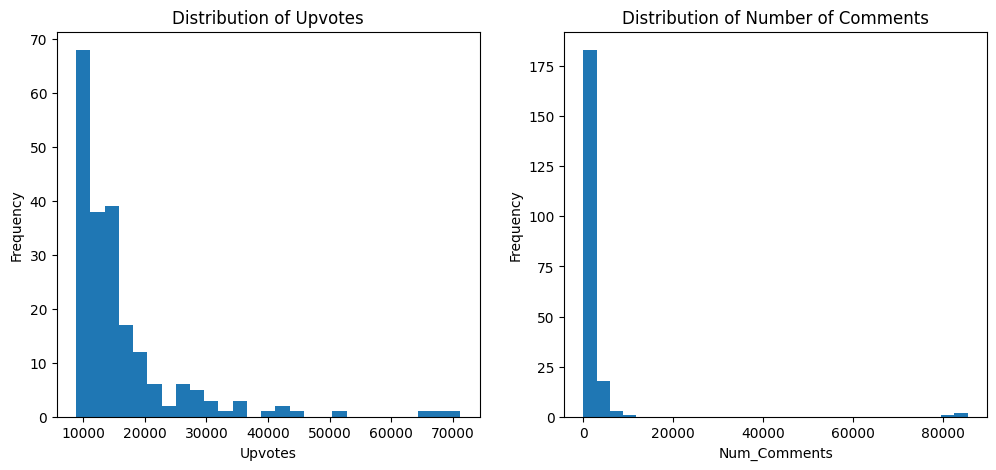

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Upvotes histogram 
axes[0].hist(top_reddit_posts['Upvotes'], bins='auto')
axes[0].set_title('Distribution of Upvotes')
axes[0].set_xlabel('Upvotes')
axes[0].set_ylabel('Frequency')

# Comments histogram
axes[1].hist(top_reddit_posts['Num_Comments'], bins='auto')
axes[1].set_title('Distribution of Number of Comments')
axes[1].set_xlabel('Num_Comments')
axes[1].set_ylabel('Frequency')

plt.show()

In [113]:
# Remove ALL old VADER columns if they exist
cols_to_remove = [
    'Title_compound', 'Title_Sent',
    'title_neg', 'title_neu', 'title_pos', 
    'title_compound'
]

top_reddit_posts.drop(
    columns=[c for c in cols_to_remove if c in top_reddit_posts.columns],
    inplace=True
)

In [114]:
# --- remove old sentiment columns if they exist ---
cols_to_remove = ['title_compound', 'Title_Sent']
top_reddit_posts.drop(columns=[c for c in cols_to_remove if c in top_reddit_posts.columns],
                      inplace=True)

# --- calculate new sentiment ---
results = []

for headline in top_reddit_posts['Title']:
    sentiment = sia.polarity_scores(headline)
    compound = sentiment['compound']

    if compound >= 0.05:
        sentiment_class = 'Positive'
    elif compound <= -0.05:
        sentiment_class = 'Negative'
    else:
        sentiment_class = 'Neutral'
    
    results.append({
        'Title_compound': compound,
        'Title_Sent': sentiment_class
    })

sentimental_title = pd.DataFrame(results)

# --- attach to table ---
top_reddit_posts = pd.concat([top_reddit_posts, sentimental_title], axis=1)

In [115]:
# Title word count
top_reddit_posts["title_word_count"] = top_reddit_posts["Title"].astype(str).str.split().str.len()

# Body word count
top_reddit_posts["body_word_count"] = top_reddit_posts["Body"].astype(str).str.split().str.len()

In [116]:
top_reddit_posts

,Title,Upvotes,Flair,Num_Comments,Body,Created_UTC,Post_ID,Title_compound,Title_Sent,title_word_count,body_word_count
0,Reddit may force Apollo and third-party client...,71198,iOS,4376,,1685557335.0,13wtu6z,0.0000,Neutral,17,0
1,Join the battle for net neutrality!!! We don’t...,68359,None,482,,1511319098.0,7enkwk,-0.4530,Negative,17,0
2,Popular iOS Reddit client Apollo will shut dow...,64935,Discussion,2089,,1686245287.0,144ffin,0.4215,Positive,11,0
3,iPhone 12 does not come with power charger or ...,51119,iPhone,7335,,1602610936.0,jaidc5,0.0000,Neutral,13,0
4,"In light of Facebook's whining about Apple, re...",44016,Potentially Misleading Title,1677,,1608171285.0,kenyhx,-0.2263,Negative,19,0
...,...,...,...,...,...,...,...,...,...,...,...
203,"After 15 Years, Apple Prepares to Break Up Wit...",8998,Mac,1251,,1592744092.0,hd6hcy,0.0000,Neutral,10,0
204,My kid managed to pass Screen time limit,8958,None,457,When iOS 12 came out I limited my 7-year old s...,1537705923.0,9i8194,0.0000,Neutral,8,90
205,Tim Cook: Users Who Want to Sideload Apps Can ...,8958,iOS,2130,,1636478230.0,qq8ft1,0.4019,Positive,19,0
206,The six-year-old iPhone 6S and 6S Plus will ge...,8929,iPhone,1020,,1623180759.0,nvcacz,0.0000,Neutral,14,0


## Step 3: Perform exploratory analysis 

In [117]:
#  Base English stopwords 
stop_words = set(stopwords.words('english'))

#  Add my custom unwanted words 
custom_stopwords = {
    'vent', 'dogs', 'today', 'like', 'time', 'anyone', 'pet'
}

# Merge them together
stop_words.update(custom_stopwords)

# Clean and extract words from titles 
title_clean = top_reddit_posts['Title'].astype(str).str.lower()

words = []
for t in title_clean:
    # extract unique words from each title (no duplicates per title)
    unique_words = set(re.findall(r'\b[a-zA-Z]{3,}\b', t))
    for w in unique_words:
        if w not in stop_words:
            words.append(w)

#  Count word frequency 
word_counts = Counter(words)

#  Top 30 most frequent words 
top_words = word_counts.most_common(15)

#  Show results 
print("\nTop 15 most frequent words in Reddit post titles:")
for word, count in top_words:
    print(f"{word:15} {count}")


Top 15 most frequent words in Reddit post titles:
apple           137
iphone          38
ios             24
app             24
new             18
reddit          15
facebook        15
tim             15
pro             15
apollo          14
store           13
cook            13
says            11
apps            10
privacy         10


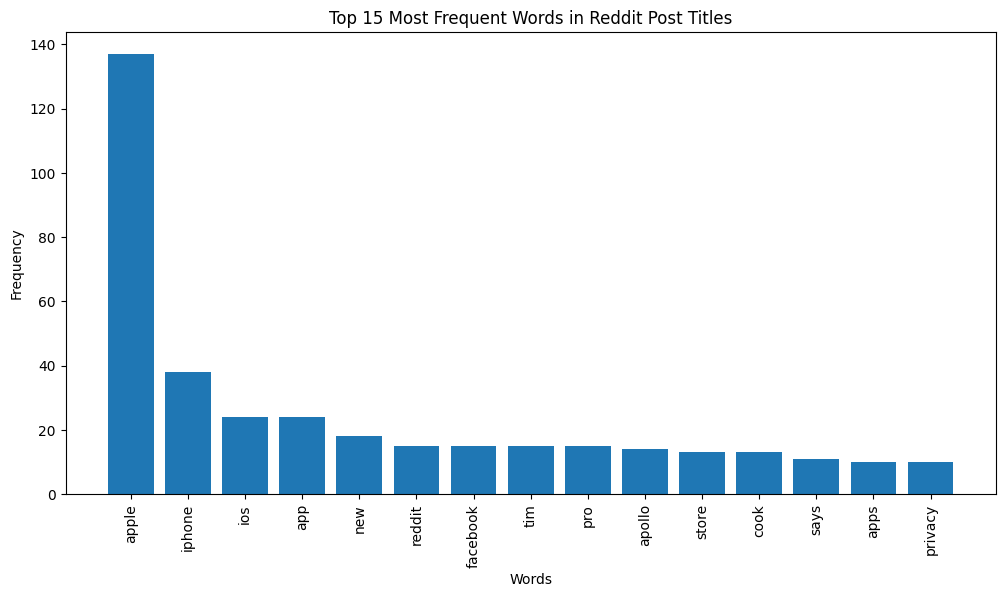

In [118]:
plt.figure(figsize=(12, 6))
words, counts = zip(*top_words)
plt.bar(words, counts)
plt.xticks(rotation=90)
plt.title('Top 15 Most Frequent Words in Reddit Post Titles')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.show()